## Exercises XP

In [236]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [237]:
!unzip /content/drive/MyDrive/BootGenAI/titanic_dataset.zip

Archive:  /content/drive/MyDrive/BootGenAI/titanic_dataset.zip
replace titanic dataset/gender_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: titanic dataset/gender_submission.csv  
replace titanic dataset/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: titanic dataset/test.csv  
replace titanic dataset/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: titanic dataset/train.csv  


### Exercise 1: Duplicate Detection and Removal

In [238]:
import pandas as pd

df = pd.read_csv("/content/titanic dataset/train.csv")
# Check initial shape
print("Initial shape:", df.shape)

Initial shape: (891, 12)


In [239]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [241]:
#identify duplication rows
df.duplicated().sum()

np.int64(0)

In [242]:
df_cleaned = df.drop_duplicates()

In [243]:
print(df.shape[0]) #gives the number of rows in the original dataset.
print(df_cleaned.shape[0]) #gives the number of rows after duplicates are removed.

891
891


### Exercise 2: Handling Missing Values

In [244]:
#Identify columns in the Titanic dataset with missing values.
missing_val = df.isnull().sum() #Age, Cabin and Embarked
print(missing_val)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [245]:
#Removing missing data
df = df.dropna(subset=["Embarked"])
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [246]:
print(df["Age"])
print("Max Age : ",df["Age"].max())
print("Min Age : ",df["Age"].min())

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 889, dtype: float64
Max Age :  80.0
Min Age :  0.42


In [247]:
#Imputaion with Median is better if the data is skewed or has outliers.
df['Age'].fillna(df['Age'].median(), inplace=True)

print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


/tmp/ipython-input-717162288.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-717162288.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'].fillna(df['Age'].median(), inplace=True)


In [248]:
#or
from sklearn.impute import SimpleImputer

# Create imputer with constant strategy
imputer = SimpleImputer(strategy="mean", fill_value=0.2)

# Apply imputer to Age column
df['Age'] = imputer.fit_transform(df[['Age']])

# Check result
print(df['Age'])


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 889, dtype: float64


/tmp/ipython-input-3775723903.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = imputer.fit_transform(df[['Age']])


In [249]:
# Fill Cabin with "Unknown"
df_fill_cabin = df['Cabin'].fillna("Unknown")

# or Drop the column because there is too much missing value
df.drop(columns='Cabin', inplace=True)


/tmp/ipython-input-363026198.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns='Cabin', inplace=True)


### Exercise 3: Feature Engineering

In [250]:
df['FamilySize'] = df['SibSp'] + df['Parch']+1
print(df['FamilySize'])

df["Title"] = df["Name"].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]
print(df["Title"])

#or
#df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: FamilySize, Length: 889, dtype: int64
0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 889, dtype: object


/tmp/ipython-input-4087142375.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FamilySize'] = df['SibSp'] + df['Parch']+1
/tmp/ipython-input-4087142375.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Title"] = df["Name"].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]


In [251]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'Title'],
      dtype='object')

In [252]:
#Group Rare Titles
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

/tmp/ipython-input-41309874.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Title'] = df['Title'].replace(rare_titles, 'Rare')


In [253]:
#One-Hot Encoding (Nominal categories)
df_onehot= pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'])

In [254]:
df_onehot.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'FamilySize', 'Sex_female', 'Sex_male', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mlle',
       'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rare',
       'Title_the Countess'],
      dtype='object')

### Exercise 4: Outlier Detection and Handling

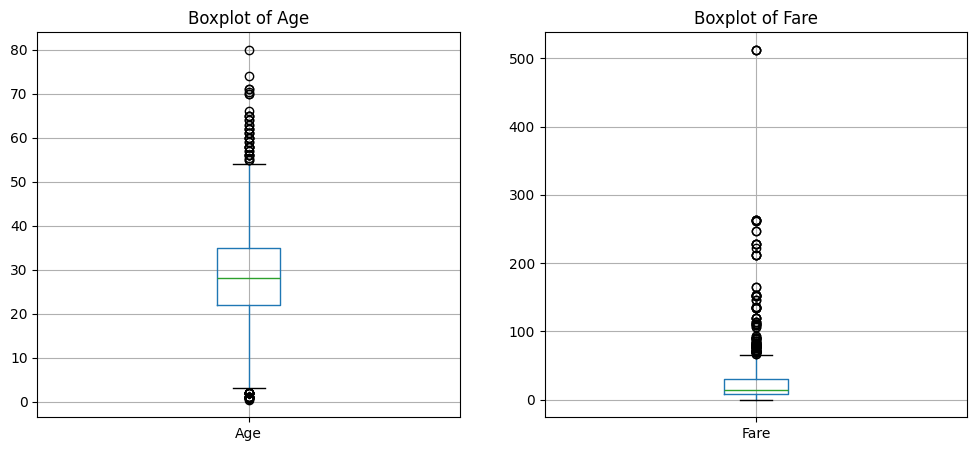

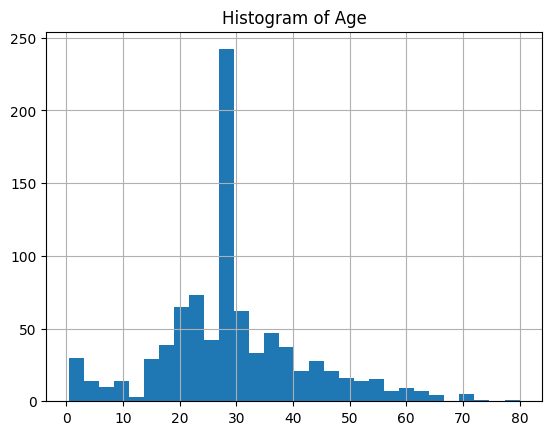

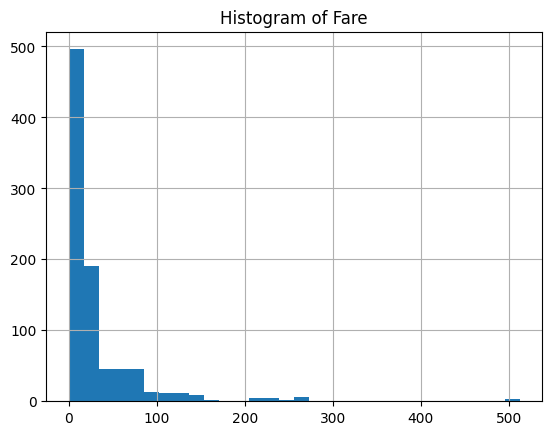

In [255]:
import matplotlib.pyplot as plt

# Boxplot for Age and Fare
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
df.boxplot(column='Age')
plt.title("Boxplot of Age")

plt.subplot(1,2,2)
df.boxplot(column='Fare')
plt.title("Boxplot of Fare")
plt.show()

# Histogram
df['Age'].hist(bins=30)
plt.title("Histogram of Age")
plt.show()

df['Fare'].hist(bins=30)
plt.title("Histogram of Fare")
plt.show()

In [256]:
#IQR Method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

fare_outliers = df[(df['Fare'] < lower_limit) | (df['Fare'] > upper_limit)]
print(fare_outliers.shape)

(114, 13)


In [257]:
#IQR Method
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

age_outliers = df[(df['Age'] < lower_limit) | (df['Age'] > upper_limit)]
print(age_outliers.shape)

(65, 13)


In [258]:
#Handle Outliers
upper_Age_cap = df['Age'].quantile(0.98)
df['Age_capped'] = df['Age'].clip(upper=upper_Age_cap)

upper_Fare_cap = df['Fare'].quantile(0.98)
df['Fare_capped'] = df['Fare'].clip(upper=upper_Fare_cap)

/tmp/ipython-input-4192269745.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age_capped'] = df['Age'].clip(upper=upper_Age_cap)
/tmp/ipython-input-4192269745.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_capped'] = df['Fare'].clip(upper=upper_Fare_cap)


In [259]:
#log Transformation
import numpy as np

df['Age_log'] = np.log1p(df['Age'])  # log(1+Age)

df['Fare_log'] = np.log1p(df['Fare'])  # log(1+Fare)

/tmp/ipython-input-2706735705.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age_log'] = np.log1p(df['Age'])  # log(1+Age)
/tmp/ipython-input-2706735705.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_log'] = np.log1p(df['Fare'])  # log(1+Fare)


In [260]:
#row removal
df_no_outliers = df[(df['Age'] >= lower_limit) & (df['Age'] <= upper_limit)]
print(df_no_outliers.shape)

df_no_outliers = df[(df['Fare'] >= lower_limit) & (df['Fare'] <= upper_limit)]
print(df_no_outliers.shape)

(824, 17)
(735, 17)


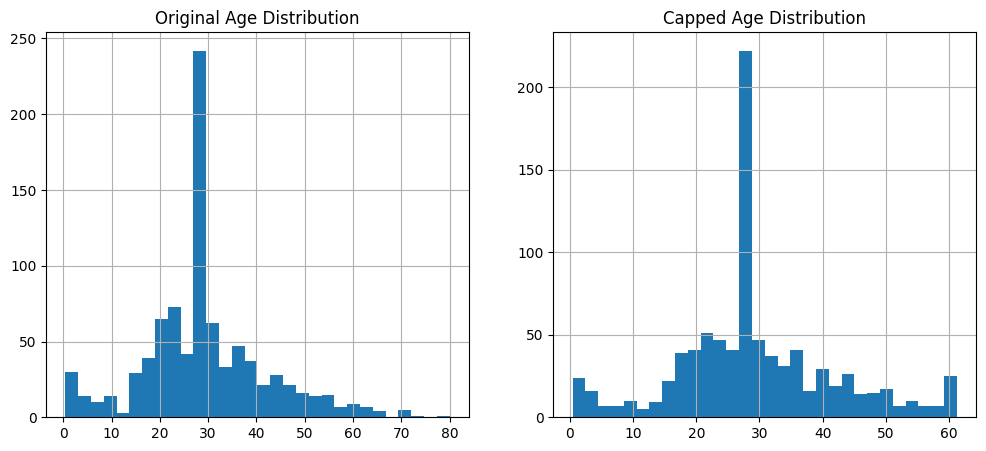

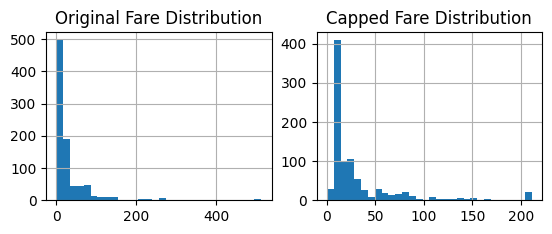

In [261]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df['Age'].hist(bins=30)
plt.title("Original Age Distribution")

plt.subplot(1,2,2)
df['Age_capped'].hist(bins=30)
plt.title("Capped Age Distribution")

plt.show()

plt.subplot(2,2,1)
df['Fare'].hist(bins=30)
plt.title("Original Fare Distribution")

plt.subplot(2,2,2)
df['Fare_capped'].hist(bins=30)
plt.title("Capped Fare Distribution")

plt.show()

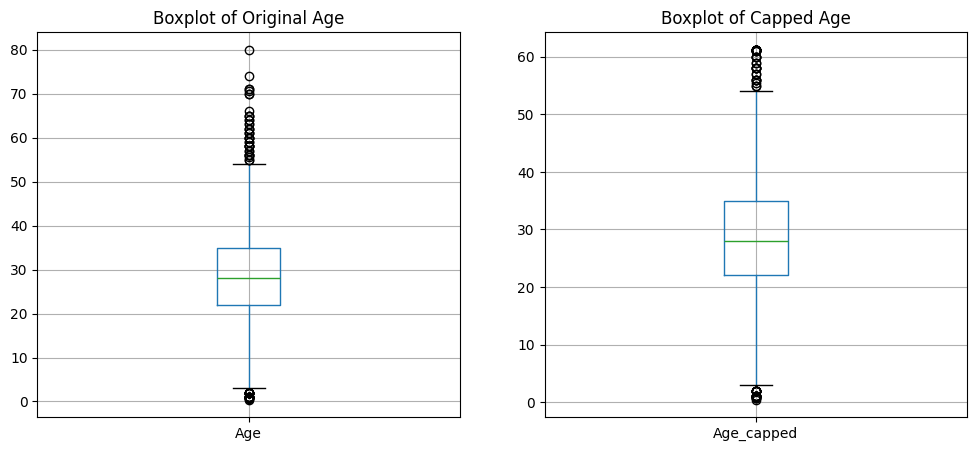

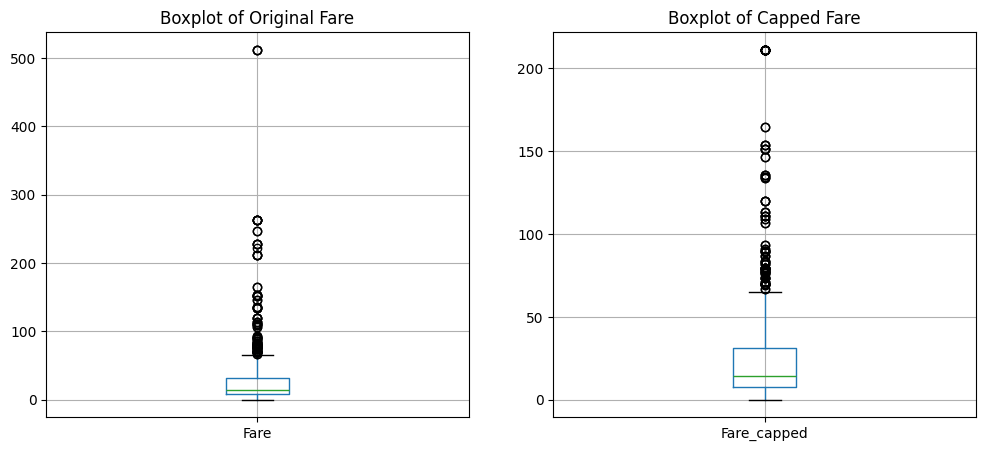

In [262]:
# Boxplot for Age and Fare
plt.figure(figsize=(12,5))

# Original Age
plt.subplot(1,2,1)
df.boxplot(column='Age')
plt.title("Boxplot of Original Age")

# Capped Age
plt.subplot(1,2,2)
df.boxplot(column='Age_capped')
plt.title("Boxplot of Capped Age")

plt.figure(figsize=(12,5))

# Original Fare
plt.subplot(1,2,1)
df.boxplot(column='Fare')
plt.title("Boxplot of Original Fare")

# Capped Fare
plt.subplot(1,2,2)
df.boxplot(column='Fare_capped')
plt.title("Boxplot of Capped Fare")

plt.show()


### Exercise 5: Data Standardization and Normalization

In [263]:
#Get All Numerical Columns in a DataFrame
# numerical_cols = df.select_dtypes(include='number').columns
# print(numerical_cols)

numerical_cols = ['Age_capped', 'Fare_capped']


In [264]:
#StandardScale for normally distrubuted features
from sklearn.preprocessing import StandardScaler,  MinMaxScaler

scaler_standard = StandardScaler()
df['Age_scaled'] = scaler_standard.fit_transform(df[['Age_capped']])

scaler_minmax = MinMaxScaler()
df['Fare_scaled'] = scaler_minmax.fit_transform(df[['Fare_capped']])

print(df[['Age_capped', 'Age_scaled']].describe())
print(df[['Fare_capped', 'Fare_scaled']].describe())


       Age_capped    Age_scaled
count  889.000000  8.890000e+02
mean    29.196839  8.791867e-17
std     12.643921  1.000563e+00
min      0.420000 -2.277224e+00
25%     22.000000 -5.695140e-01
50%     28.000000 -9.471056e-02
75%     35.000000  4.592268e-01
max     61.240000  2.535701e+00
       Fare_capped  Fare_scaled
count   889.000000   889.000000
mean     30.567524     0.144638
std      39.881074     0.188708
min       0.000000     0.000000
25%       7.895800     0.037361
50%      14.454200     0.068394
75%      31.000000     0.146685
max     211.337500     1.000000


/tmp/ipython-input-423737212.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age_scaled'] = scaler_standard.fit_transform(df[['Age_capped']])
/tmp/ipython-input-423737212.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_scaled'] = scaler_minmax.fit_transform(df[['Fare_capped']])


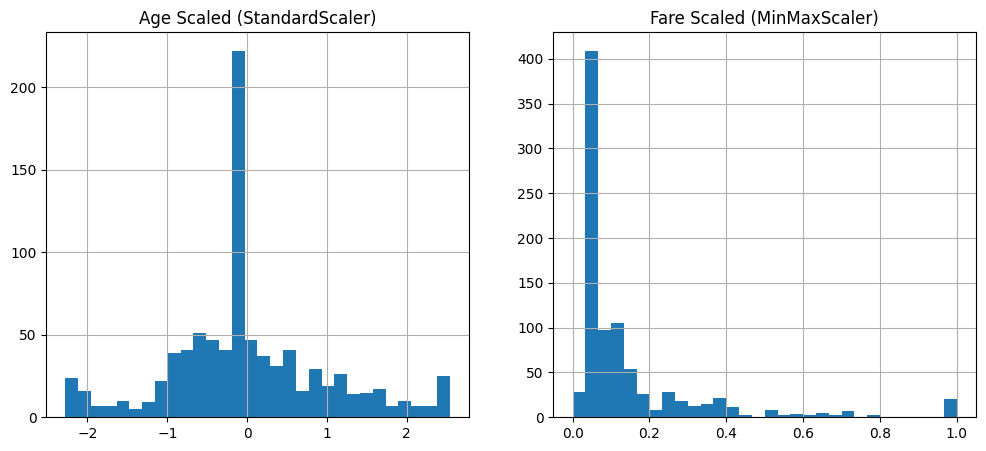

In [265]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
df['Age_scaled'].hist(bins=30)
plt.title("Age Scaled (StandardScaler)")

plt.subplot(1,2,2)
df['Fare_scaled'].hist(bins=30)
plt.title("Fare Scaled (MinMaxScaler)")
plt.show()


### Exercise 6: Feature Encoding

In [266]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)


Index(['Name', 'Sex', 'Ticket', 'Embarked', 'Title'], dtype='object')


In [267]:
df= pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

In [268]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Pclass_encoded'] = le.fit_transform(df['Pclass'])

In [269]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'FamilySize', 'Age_capped', 'Fare_capped', 'Age_log',
       'Fare_log', 'Age_scaled', 'Fare_scaled', 'Sex_male', 'Embarked_Q',
       'Embarked_S', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr',
       'Title_Mrs', 'Title_Ms', 'Title_Rare', 'Title_the Countess',
       'Pclass_encoded'],
      dtype='object')

###  Exercise 7: Data Transformation for Age Feature

In [270]:
import pandas as pd

bins = [0, 12, 18, 60, 100]   # bornes des groupes
labels = ['Child', 'Teen', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age_capped'], bins=bins, labels=labels, right=False) #On utilise pd.cut() pour découper la colonne Age_capped en intervalles


In [271]:
#One-Hot Encoding
df = pd.get_dummies(df, columns=['AgeGroup'], drop_first=True)

In [272]:
print(df.filter(like='AgeGroup')[22:34])


    AgeGroup_Teen  AgeGroup_Adult  AgeGroup_Senior
22           True           False            False
23          False            True            False
24          False           False            False
25          False            True            False
26          False            True            False
27          False            True            False
28          False            True            False
29          False            True            False
30          False            True            False
31          False            True            False
32          False            True            False
33          False           False             True
